In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image


In [69]:
class FootballState(TypedDict):
    passes_completed: int
    passes_attempted: int
    pass_accuracy: float
    

    shots_on_target: int
    shots_off_target: int
    total_shots: int
    shot_accuracy: float

    dribbles_completed: int
    dribbles_attempted: int
    dribble_success_rate: float

    summary: str


In [90]:
def compute_pass_accuracy(state: FootballState) -> FootballState:
    
    pa= state['passes_completed']/ state['passes_attempted']
    pap = pa * 100
    return {'pass_accuracy': pap}



In [91]:
def compute_shot_accuracy(state: FootballState) -> dict:
    shots_on_target = state['shots_on_target']
    shots_off_target = state['shots_off_target']
    total_shots = shots_on_target + shots_off_target
    
    if total_shots == 0:
        return {
            'total_shots': 'N/A',
            'shot_accuracy': 'N/A'
        }
    else:
        accuracy = (shots_on_target / total_shots) * 100
        return {
            'total_shots': total_shots,
            'shot_accuracy': accuracy
        }

In [92]:
def compute_dribble_success_rate(state: FootballState) -> dict:
    dribbles_completed = state['dribbles_completed']
    dribbles_attempted = state['dribbles_attempted']

    
    success_rate = (dribbles_completed / dribbles_attempted) * 100
    print(f"Dribble Success Rate: {success_rate:.2f}%")
    return {'dribble_success_rate': success_rate}

In [93]:
def generate_summary(state: FootballState) -> dict:
    summary = (
        f"Pass Accuracy: {state['pass_accuracy']}\n"
        f"Shot Accuracy: {state['shot_accuracy']}\n"
        f"Dribble Success Rate: {state['dribble_success_rate']}\n"
    )
    print("Summary of Football Statistics:")
    print(summary)
    return {'summary': summary}

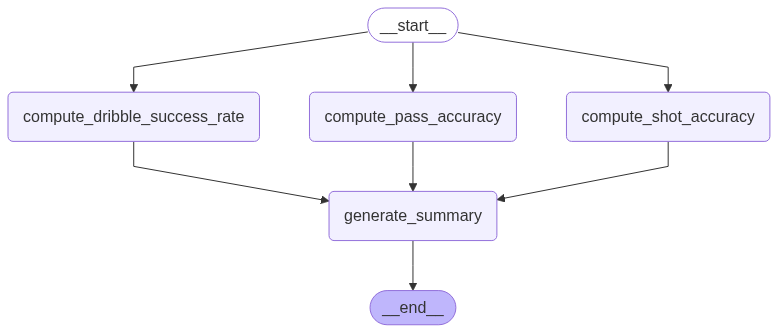

In [94]:
graph = StateGraph(FootballState)

# nodes
# parallel nodes for computing statistics
graph.add_node("compute_pass_accuracy", compute_pass_accuracy)
graph.add_node("compute_shot_accuracy", compute_shot_accuracy)
graph.add_node("compute_dribble_success_rate", compute_dribble_success_rate)

# join points for parallel nodes
graph.add_node("generate_summary", generate_summary)

# edges
graph.add_edge(START, "compute_pass_accuracy")
graph.add_edge(START, "compute_shot_accuracy")
graph.add_edge(START, "compute_dribble_success_rate")

graph.add_edge("compute_pass_accuracy", "generate_summary")
graph.add_edge("compute_shot_accuracy", "generate_summary")
graph.add_edge("compute_dribble_success_rate", "generate_summary")

graph.add_edge("generate_summary", END)

# compile
graph.compile()

In [95]:
workflow= graph.compile()

In [96]:
initial_state = FootballState(
    passes_completed=180,           
    passes_attempted=200,
    shots_on_target=10,
    shots_off_target=5,
    dribbles_completed=20,
    dribbles_attempted=25,
    pass_accuracy=0.0,
    shot_accuracy=0.0,
    total_shots=0,
    dribble_success_rate=0.0,
    summary=""
)
final_state = workflow.invoke(initial_state)
print(final_state['summary'])

Dribble Success Rate: 80.00%
Summary of Football Statistics:
Pass Accuracy: 90.0
Shot Accuracy: 66.66666666666666
Dribble Success Rate: 80.0

Pass Accuracy: 90.0
Shot Accuracy: 66.66666666666666
Dribble Success Rate: 80.0

